# Разработка нейросетевой модели машинного обучения для прогнозирования температуры звезды

**Описание проекта:**

Обсерватория «Небо на ладони» хочет автоматизировать определение температуры звёзд по их характеристикам с помощью нейросетевой модели. Заказчик предполагает, что модель сможет точнее предсказывать температуру по сравнению с классическими рассчетными методами. Для этого метрика RMSE не должна превышать 4500. В распоряжении имеется датасет с параметрами 240 звёзд. 

**Цель:** \
Создание модели машинного обучения для предсказания температуры звезды для упрощения и ускорения ее классификации.

**Ход исследования:**
- Подготовка данных: загрузка и первичное изучение датасета, содержащего информацию о звездах. Предобработка данных при необходимости.
- Иследовательский анализ: выявление закономерностей, аномалий и особенностей распределения в данных. Визуализация и предварительные выводы.
- Подготовка данных: деление данных на обучающую и тестовую выборки. Масштабирование и кодировка признаков при необходимости.
- Разработка baseline модели: выбор архитектуры модели, подбор количества слоев, нейронов и функций активации. 
- Улучшение нейросети: дальнейшее улучшение модели с помощью перебора параметров: «dropout» и «размер батча». Архитектура остается без изменений. Целевое значение метрики RMSE для улучшенной модели - 4500.

**Описание данных**: \
`L/Lo` — светимость звезды относительно Солнца \
`R/Ro` — радиус звезды относительно Солнца \
`Mv` — абсолютная звёздная величина \
`Color` — цвет звезды \
`Type` — тип звезды (от карликов до гипергигантов) \
`Temperature` — абсолютная температура (целевая переменная) 

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import phik

import torch
import torch.nn as nn
from math import ceil

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import optuna
from optuna.samplers import TPESampler

from src.data_prepare import data_info, snake_case
import src.visualization as visual

#Установка единого формата данных
pd.options.display.float_format = '{:,.3f}'.format
pd.options.mode.chained_assignment = None

# Установка опции для отображения максимальной ширины столбца
pd.set_option('display.max_colwidth', None)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42


## Загрузка данных

In [2]:
data = pd.read_csv('data/stars_class.csv', index_col=0)
data_info(data)


ОБЗОР ДАТАСЕТА
Основная информация:
Размер данных: 240 строк × 6 столбцов


,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color
0,3068,0.002,0.170,16.120,0,Red
1,3042,0.001,0.154,16.600,0,Red


<class 'pandas.core.frame.DataFrame'>
Index: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star type               240 non-null    int64  
 5   Star color              240 non-null    object 
dtypes: float64(3), int64(2), object(1)
memory usage: 13.1+ KB


,count,mean,std,min,25%,50%,75%,max
Temperature (K),240.000,"10,497.462","9,552.425","1,939.000","3,344.250","5,776.000","15,055.500","40,000.000"
Luminosity(L/Lo),240.000,"107,188.362","179,432.245",0.000,0.001,0.071,"198,050.000","849,420.000"
Radius(R/Ro),240.000,237.158,517.156,0.008,0.103,0.762,42.750,"1,948.500"
Absolute magnitude(Mv),240.000,4.382,10.533,-11.920,-6.232,8.313,13.697,20.060
Star type,240.000,2.500,1.711,0.000,1.000,2.500,4.000,5.000


Пропущенные значения:
Пропущенных значений нет.
Наличие дубликатов:
Явных дубликатов нет
Уникальность id
Все значения в поле с идентификатором уникальны


Названия столбцов приведем к общепринятому формату 'snake_case'.

In [3]:
data.columns = snake_case(data.columns)
data.columns


Index(['temperature', 'luminosity', 'radius', 'absolute_magnitude',
       'star_type', 'star_color'],
      dtype='object')

Поле `star_type` содержит закодированные категориальные значения - тип звезды. Соответственно, для корректной обработки признака необходимо рассматривать его в дальнейшем как категориальный. Изменим тип данных в это столбце на строковый. 

In [4]:
data['star_type'] = data['star_type'].astype('object')


<b>Вывод по разделу "Загрузка данных"</b>

- Названия столбцов приведены к общепринятому формату 'snake_case'.
- В данных нет пропусков и явных дубликатов.
- Тип данных в поле `star_type` изменен на строковые, т.к. эти данные по своей природе являются категориальными. В остальных полях типы данных соответствуют информации в таблице. 
- Средние и медианные значения для количественных переменных  отличаются значительно, что может говорить о наличии выбросов или аномалий. Медиана для данных о светимости и радиусе планеты знаительно меньше, чем среднее. Это говорит о том, что распределение имеет правосторонню ассиметрию: большинство значений сосредоточено слева (меньшие значения), а справа распределение имеет "длинный хвост". Об этом же говорит и сравнение минимальных и максимальных значений в этих полях. Судя по информации из открытых источников, такая ситуация нормальна для космических наблюдений.
- Количественные признаки лежат в различных диапазонах, перед подачей в модель необходимо масштабирование.

## Предобработка и анализ данных

Проверим категориальный признак со строковыми значениями на наличие неявных дубликатов.

In [5]:
print('Уникальные значения в поле "star_color":', data['star_color'].unique())


Уникальные значения в поле "star_color": ['Red' 'Blue White' 'White' 'Yellowish White' 'Blue white'
 'Pale yellow orange' 'Blue' 'Blue-white' 'Whitish' 'yellow-white'
 'Orange' 'White-Yellow' 'white' 'Blue ' 'yellowish' 'Yellowish'
 'Orange-Red' 'Blue white ' 'Blue-White']


Уникальные значения в поле `star_color` содержат дубликаты. Например, можно однозначно утверждать, что 'Blue White' и 'Blue white' - это одно и то же. Приведем текст к нижнему регистру и запишем названия для единообразия в snake_case.

In [6]:
data['star_color'] = snake_case(data['star_color'])
print('Уникальные значения в поле "star_color":', data['star_color'].unique())


Уникальные значения в поле "star_color": ['red' 'blue_white' 'white' 'yellowish_white' 'pale_yellow_orange' 'blue'
 'whitish' 'yellow_white' 'orange' 'white_yellow' 'yellowish' 'orange_red']


Обработаем также явно одинаковые значения, которые отличаются только порядком слов: 'white_yellow' и 'yellow_white'.

In [7]:
data['star_color'] = data['star_color'].str.replace('white_yellow', 'yellow_white')
print('Уникальные значения в поле "star_color":', data['star_color'].unique())
print('Кол-во уникальных значений в поле "star_color":', len(data['star_color'].unique()))


Уникальные значения в поле "star_color": ['red' 'blue_white' 'white' 'yellowish_white' 'pale_yellow_orange' 'blue'
 'whitish' 'yellow_white' 'orange' 'yellowish' 'orange_red']
Кол-во уникальных значений в поле "star_color": 11


Как правило, выделяют 7 основных классов звезд, которым соответствуют 7 цветов. В основных классах нет градаций цвета (например, желтоватый - 'yellowish') и эти значения явстречаются достаточно редко. Укрупним категории в поле `star_color` до основных классов.

In [8]:
data['star_color'] = data['star_color'].str.replace('whitish', 'white')
data['star_color'] = data['star_color'].str.replace('yellowish_white', 'yellow_white')
data['star_color'] = data['star_color'].replace(['yellowish', 'pale_yellow_orange'], 'yellow')
data['star_color'] = data['star_color'].str.replace('orange_red', 'orange')

print('Уникальные значения в поле "star_color":', data['star_color'].unique())
print('Кол-во уникальных значений в поле "star_color":', len(data['star_color'].unique()))


Уникальные значения в поле "star_color": ['red' 'blue_white' 'white' 'yellow_white' 'yellow' 'blue' 'orange']
Кол-во уникальных значений в поле "star_color": 7


In [9]:
data.duplicated().sum()


np.int64(0)

In [10]:
cat_cols = data.select_dtypes(include='object').columns.tolist()
num_cols = data.columns.difference(cat_cols)


Рассмотрим сперва категориальные признаки.

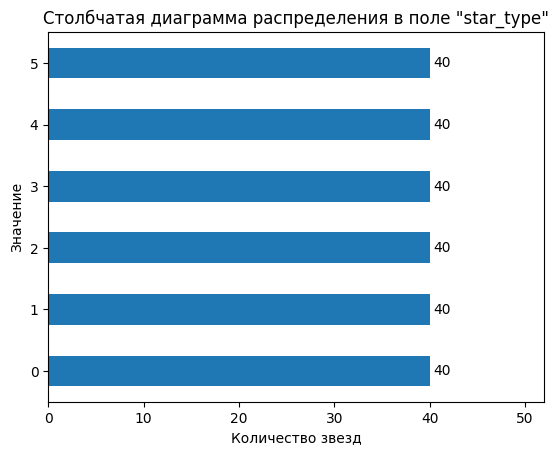

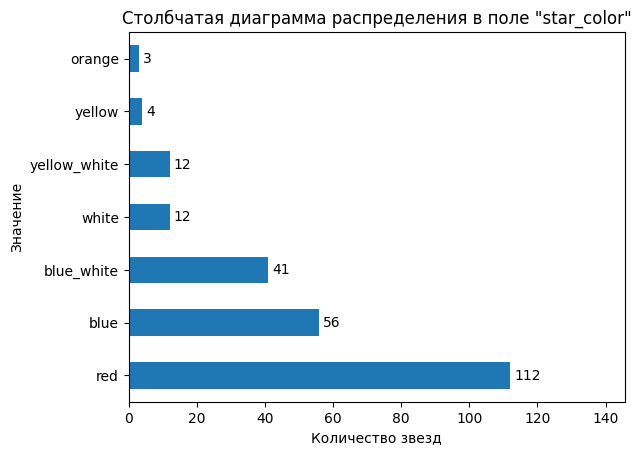

In [11]:
visual.category_graph(data, cat_cols)


Поле `star_color`: \
Чаще всего встречается значение 'red' (красный) - 112 звёзд, что составляет 47% всей выборки. Такое распределение близко к реальности, т.к. в целом "красных" звезд больше, чем всех остальных открытых звезд ([73% от общего числа](https://ru.wikipedia.org/wiki/%D0%A1%D0%BF%D0%B5%D0%BA%D1%82%D1%80%D0%B0%D0%BB%D1%8C%D0%BD%D0%B0%D1%8F_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D1%8F_%D0%B7%D0%B2%D1%91%D0%B7%D0%B4#CITEREFKarttunen_et_al.2007)). Следом идут: 'blue' — 56 и 'blue_white' — 41. Остальные цвета представлены значительно реже (от 1 до 10 звёзд).

Поле `star_type`: \
Распределение в поле абсолютно равномерное, типы от 0 до 5 встречаются ровно по 40 раз.
Возможно, это синтетически сбалансированный датасет, где каждая звезда представлена одинаковое кол-во раз. 

Учитывая, что распределение по типу звезды равномерное, имеет смысл подробнее изучить распределение остальных характеристик внутри каждого типа. Если окажется, что тип чётко определяет диапазоны этих признаков, это может быть полезно для лучшего понимания структуры данных. 

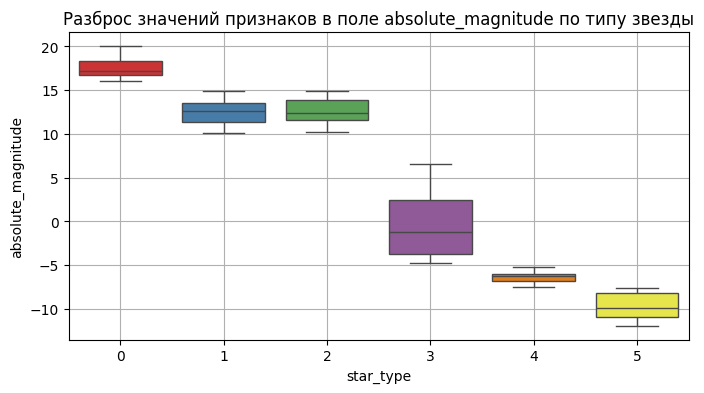

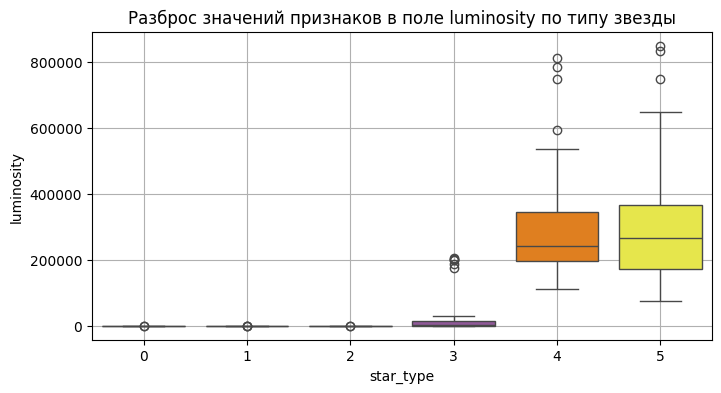

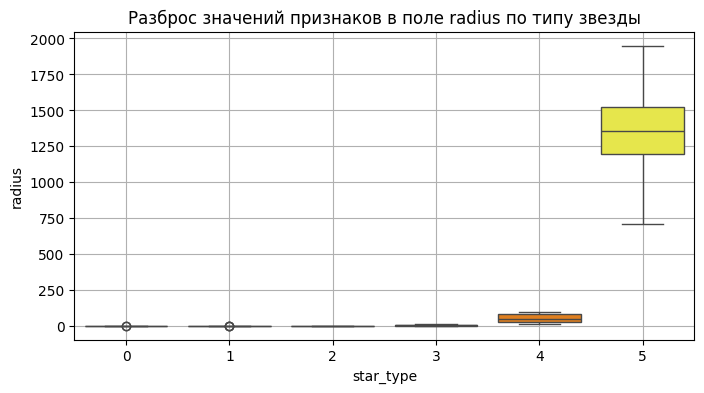

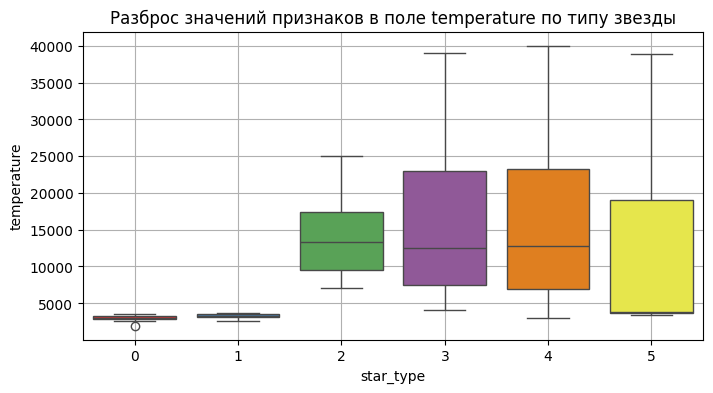

In [12]:
for col in num_cols:
    visual.boxplots(data, col)


По ящикам с усами можно сказать, что характеристики звезды очень сильно зависят от типа. 
- В поле `absolute_magnitude` (абс.звездная величина) наблюдается достаточно четкое разделение значений по большинству типов. 
- В поле `luminosity` (светимость) и `radius` (относительный радиус) очень большой разрыв в значениях между 4, 5 типами и остальными. Если в обучающую выборку не попадут эти классы, скорее всего модель не сможет корректно обработать эти значения для предсказания температуры.
- Знаечения в поле `luminosity`распределены очень неоднородно между типами. Для первых четырех типов относительные значения близки к нулю, тогда как для класса "гигантов" достигают 800 тыс. Чтобы сгладить этот эффект в дальнейшем добавим дополнительные признаки: **логарифм от светимости, который позволит "сжать" правый "хвост" и квадрат от светимости**, который уменьшит разброс. Доп.признаки помогут модели лучше уловить взаимосвязи в данных, особенно в низких и средних диапазонах, не теряя информации о максимальных значениях.
- В целевом признаке `temperature` (температура) наблюдается пересечение в значениях для типов 2-5. Однако, тип 1 и 2 значительно отличается ппо температуре от остальных.

Исходя из полученных данных можно сделать вывод, что на этапе обучения модели важно увидеть данные по всем типам звезд. Тестовую и обучающую выборки необходимо делить со **стратификацией по признаку `star_type`**.

Посмотрим на распределение цвета звезд по типу.

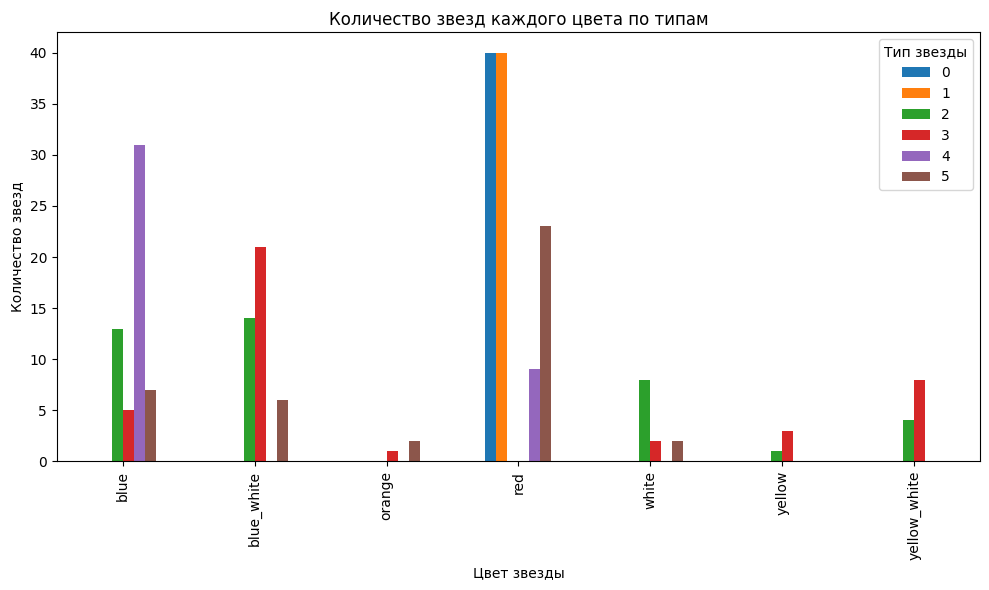

In [16]:
pivot = data.pivot_table(index='star_color', columns='star_type', aggfunc='size', fill_value=0)
pivot.plot(kind='bar', figsize=(10,6))

plt.title('Количество звезд каждого цвета по типам')
plt.xlabel('Цвет звезды')
plt.ylabel('Количество звезд')
plt.legend(title='Тип звезды')
plt.tight_layout()
plt.show();


Типы:
0, 1 - очень однородны по цвету, все звезды этих типов в выборке - красные. \
2 - цвет звезды максимально вариативен (6 вариантов). Преобладают голубые и бело-голубые звезды. \
3 - преобладают бело-голубые и желто-белые звезды. \
4 - преобладающий цвет - голубой. \
5 - тоже достаточно разнообразный по цветам тип (5 вариантов) с преобладающим красным.

На основании графиков можно построить **"портрет" типичной звезды** по каждому типу. Для удобства оформим характеристики в таблицу.

| Тип звезды          | Цвет                                                      | Температура      | Светимость    | Радиус         | Абс. звездная величина | Комментарий                                                                 |
| --------------------------------- | ------------------------------------------------------------ | ---------------- | ------------- | ------------- | ------------- | --------------------------------------------------------------------------- |
| **0 – Коричневый карлик**                 | `red`                                                        | Низкая           | Очень низкая  | Малый         | Высокая       | Холодные, тусклые и маленькие звёзды                       |
| **1 – Красный карлик**                 | `red`                                                        | Низкая           | Очень низкая      | Малый       | Высокая        | Холодные, тусклые и маленькие звёзды                       |
| **2 – Белый карлик**  | `blue`, `blue_white`, `white`, `yellow_white`,  `yellowish_white`, `pale_yellow_orange`               | Высокая          | Очень низкая      | Малый         | Высокая       | Горячие компактные звёзды     |
| **3 – Звезды главной последовательности** | `blue_white`, `blue`, `orange_red`, `yellow_white`, `whitish`, `yellowish` | Очень высокая          | Средняя      | Малый        | Средняя        | Горячие яркие и небольшие звёзды  |
| **4 – Сверхгигант**                | `blue`, `red`                                                       | Очень высокая    | Высокая | Средний       | Низкая        | Чрезвычайно горячие и яркие                                    |
| **5 – Гипергигант**                | `red`, `blue`, `blue_white`, `orange`, `white`               | Высокая | Высокая | Очень большой | Низкая        | Самые большие звезды различной температуры|


Посмотрим на распределение количественных переменных в целом.

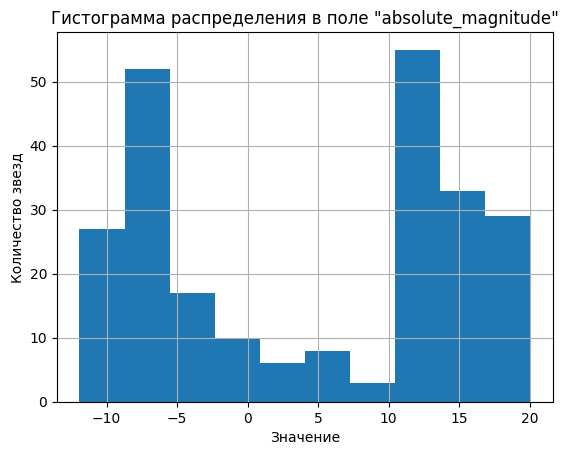

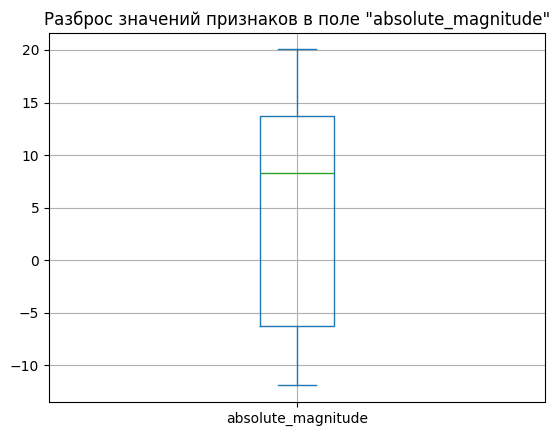

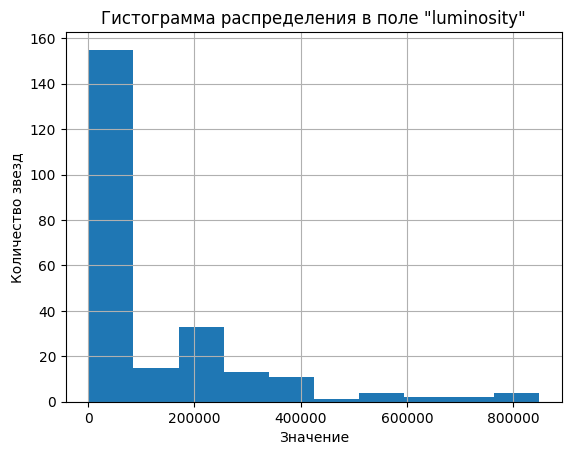

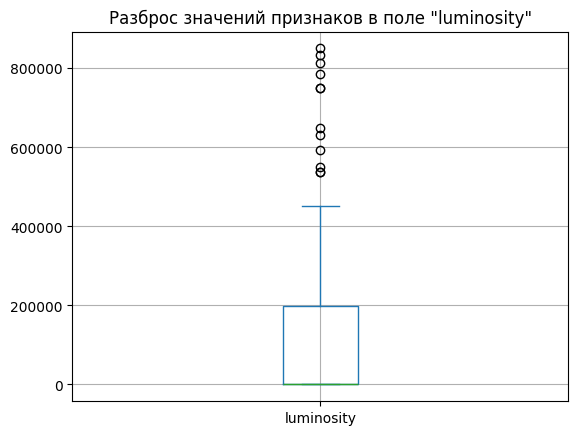

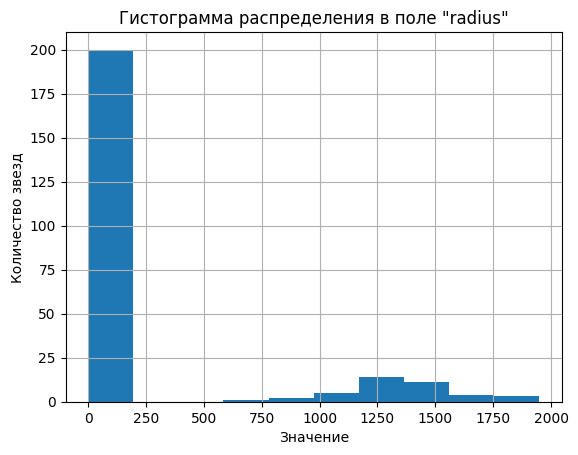

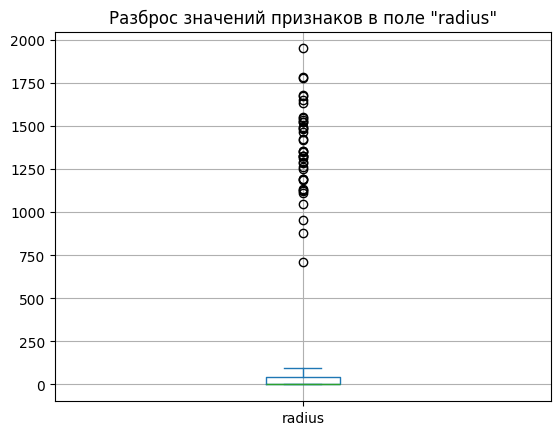

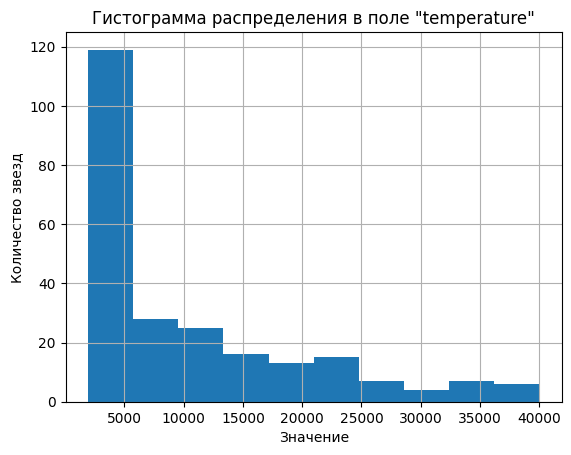

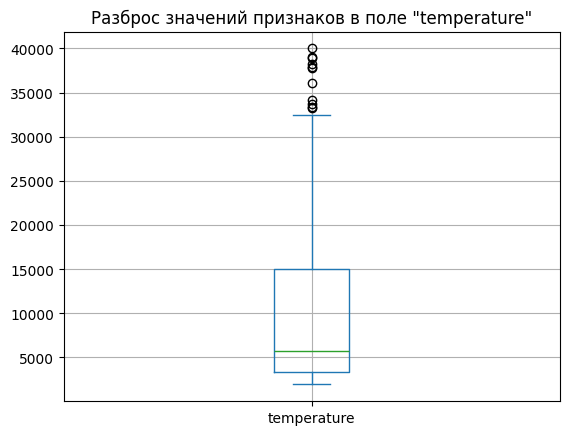

In [17]:
visual.numeric_graph(data, num_cols)


Распределения для всех характеристик отличны от нормального, ассиметричны и меют очень длинные хвосты. Ящик с усами показывает наличие выбросов, но как мы установили ранее при разбиении данных по типам звезды, небольшое количество выбросов сохраняется только в поле `luminosity`. Также мы знаем, что высокие значения светимости соответствуют гиганстким звездам по типу, диапазон светимости у которых может быть очень широким и [достигать нескольких миллионов](https://ru.wikipedia.org/wiki/%D0%93%D0%B8%D0%BF%D0%B5%D1%80%D0%B3%D0%B8%D0%B3%D0%B0%D0%BD%D1%82#%D0%A5%D0%B0%D1%80%D0%B0%D0%BA%D1%82%D0%B5%D1%80%D0%B8%D1%81%D1%82%D0%B8%D0%BA%D0%B8_%D0%B3%D0%B8%D0%BF%D0%B5%D1%80%D0%B3%D0%B8%D0%B3%D0%B0%D0%BD%D1%82%D0%B0). К тому же распределение отличается от нормального, поэтому к выявлению выбросов правилом трех сигм стоит подходить критично. В нашем случае верным будет решение оставить все данные.

Построим матрицу диаграмм рассеяния,чтобы оценить связь между количественными признаками.

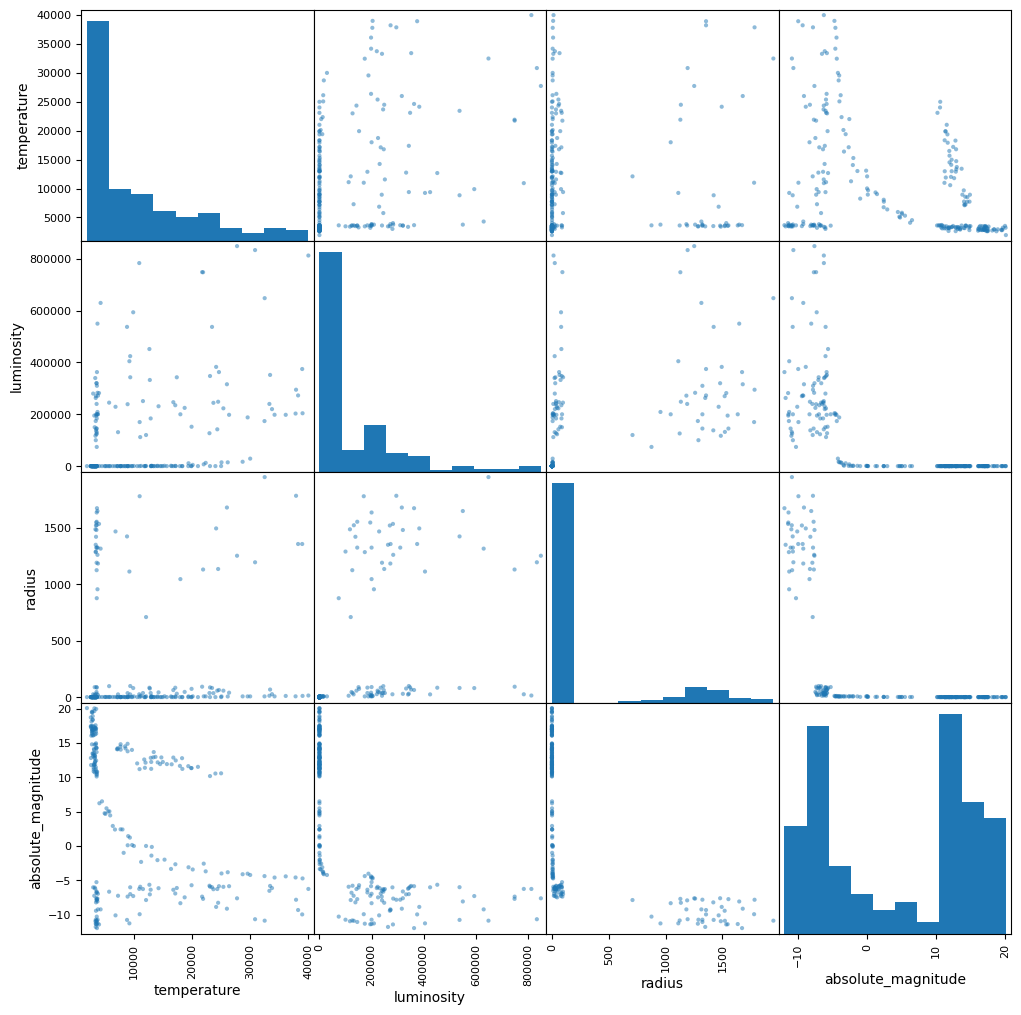

In [18]:
pd.plotting.scatter_matrix(data, figsize=(12, 12));


Как видно из диаграмм рассеяния связь между признаками нелинейная. На всех графиках просматривается тенденция к кластеризации, которая, вероятно, отражает принадлежность к определенному типу звезды. Линейные модели в данном случае будут неэффективны. При подборе архитектуры нейросети следует включить нелинейные акивации (ReLU) и попробовать разную глубину, чтобы модель была достаточно сложной для улавливания нелинейных связей.

Изучим взамосвязь между признаками и рассчитаем коэффициенты корреляции. Т.к. у нас в данных есть категориальные признаки, используем коэффициент корреляции Фи. Для наглядности построим тепловую карту.

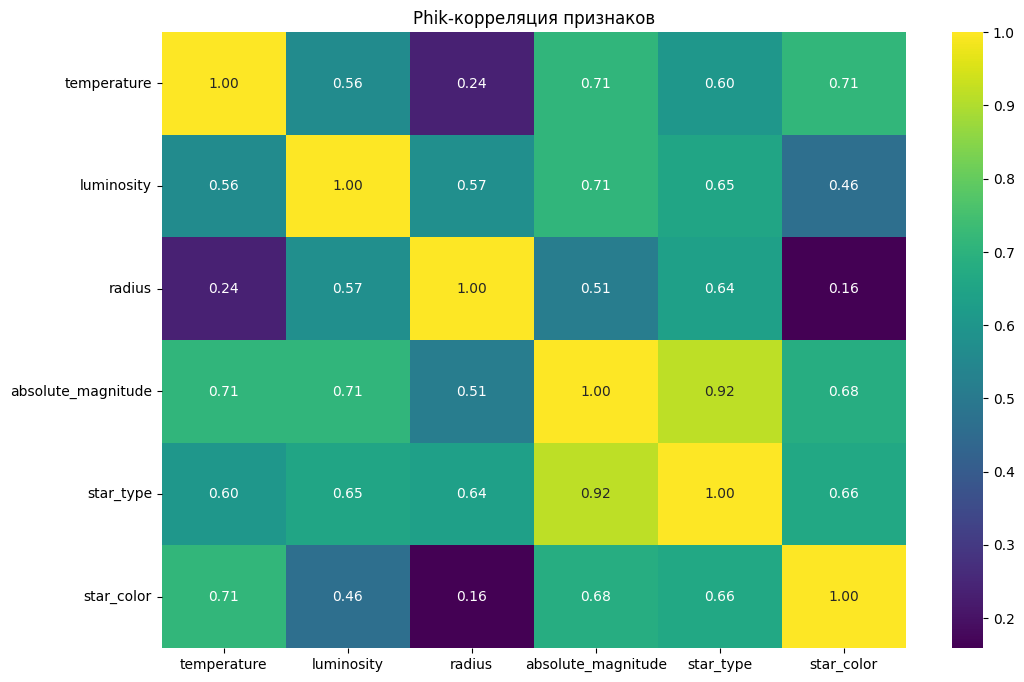

In [19]:
phik_matrix = data.phik_matrix(interval_cols=num_cols)

plt.figure(figsize=(12, 8))
sns.heatmap(phik_matrix, 
            annot=True, 
            fmt='.2f',
            cmap='viridis')
plt.title('Phik-корреляция признаков')
plt.show()


Судя по тепловой карте, самая сильная прямая связь с целевым признаком у абсолютной звездной величины. У всех остальных признаков кроме размера также заметная корреляция по шкале Чеддока (коэффициент выше 0.5).

Абс.звездная величина сильно коррелирует с типом звезды (0.92). Ранее мы выяснили, что тип звезды является по сути меткой кластера и внутри звездная величина может различаться. Таким образом, тип звезды для модели может служить дополнительным разделяющим признаком. 

<b>Вывод по разделу "Исследовательский анализ данных"</b>

1. **Данные имеют выраженную кластеризацию по `star_type`.** 
Характеристики звезд явно группируются по типам. Модель должна видеть все типы на обучении, т.к. отсутствие кластера в обучающей выборке может привести к росту ошибки на тестовой выборке. Тестовую и обучающую выборки необходимо делить со стратификацией по признаку `star_type`.

2. **Связь между признаками и целевой переменной нелинейная.**
На всех графиках просматривается тенденция к кластеризации по типу звезды. При подборе архитектуры нейросети лучший результат должна дать нейросеть с достаточной глубиной и нелинейными активациями (ReLU, GELU, ELU и т.п.), чтобы выучить разные закономерности внутри кластеров.

3. **Разные масштабы количественных признаков.**
Числовые признаки имеют разные порядки величин, поэтому перед подачей в модель обязательно масштабирование. Включим в предобработку метод StandardScaler(). Помимо этого значения в поле `luminosity`распределены неоднородно между типами (от 0 до 800 000тыс.). Чтобы сгладить этот эффект в ходе подготовки данных добавим дополнительные признаки: **логарифм от светимости, который позволит "сжать" правый "хвост" и квадрат от светимости**.

4. **Устранение неявныз дубликатов в поле `star_color`.**
Значения в поле приведены к нижнему регистру и преобразованы в snake_case. В итоге получили 11 уникальных значений. Различия между ними могут нести важную информацию для модели, поэтому принято решение не укрупнять категории.

5. **Мультиколлинеарность между признаками `absolute magnitude` и `star_type`.**
Принято решение оставить оба признака в модели, т.к. тип звезды для модели может служить дополнительным разделяющим признаком. Однако, необходимо следить за переобучением, использовать регуляризацию/dropout.

## Построение базовой нейронной сети

Добавим логарифм и квадрат от светимости для сглаживания неоднородности в данных.

In [20]:
data['luminosity_log'] = np.log(data['luminosity'])
data['luminosity_sqrt'] = np.sqrt(data['luminosity'])


Разделим выборку на группы по полю `star_type`, каждую из них разобьем на обучающую и тестовую выборки (75%/25%). Это даст более стабильное представление каждого класса, особенно учитывая, что у типов мало наблюдений и большой разброс по значениям характеристики и температуры внутри каждого типа.

Метод stratify гарантирует одинаковую пропорцию классов, но иначе работает при разделении внутри класса. В результате в тестовую выборку попадают крайние значения, которые не встречаются в обучающей. В ходе экспериментов удалось установить, что деление отдельно по каждому типу дает лучший результат по метрике.

In [21]:
train = []
test = []

for type in data['star_type'].unique():
    train_by_type, test_by_type = train_test_split(data[data['star_type']==type],
                                                   test_size=0.25,
                                                   random_state=RANDOM_STATE,
                                                   shuffle=True)
    train.append(train_by_type)
    test.append(test_by_type)
    
train = pd.concat(train).sample(frac=1, random_state=RANDOM_STATE)
test = pd.concat(test).sample(frac=1, random_state=RANDOM_STATE)
X_train = train.drop('temperature', axis=1)
X_test = test.drop('temperature', axis=1)
y_train = train['temperature'].astype(float)
y_test = test['temperature'].astype(float)


Переходим к подготовке пайплайна для предобработки признаков. Подготовим списки с названиями признаков, разделенные по предполагаемому методу обработки. Выделим категориальные переменные в один список cat_cols.

In [22]:
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.columns.difference(cat_cols)


Подготовим пайплайн для предварительной обработки данных. Для категориальных перемннных используем OneHotEncoder, дял количественных -  StandardScaler. Для энкодера установим параметр handle_unknown, который позволяет обрабатывать неизвестные категории при необходимости.

In [24]:
preprocessor = ColumnTransformer(
            transformers=[
                ("numeric", StandardScaler(), num_cols),
                ("category", OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
            ]
        )


In [25]:
preprocessor.fit(X_train)

X_train = preprocessor.transform(X_train)
X_test = preprocessor.transform(X_test)


Для корректной работы с библиотекой PyTorch переведем выборки в тензоры.

In [26]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train.values)
y_test = torch.FloatTensor(y_test.values)


Согласно ТЗ необходимо задать архитектуры базовой модели (Baseline) через класс nn.Module. Создадим класс BaselineNet, где используем 3 слоя и нелинейные функции активации (ReLU и ее производные), чтобы лучше улавливать сложные зависимости. К тому же, именно ReLU рекомендуется к использованию для регрессионных моделей. Добавим dropout для борьбы с переобучением, что особенно важно для небольших выборок как у нас.

In [27]:
class BaselineNet(nn.Module):
    def __init__(self, n_in_neurons, n_hidden_neurons_1, n_hidden_neurons_2, n_hidden_neurons_3,
                 n_out_neurons, dropout_rate_1, dropout_rate_2, dropout_rate_3):
        super(BaselineNet, self).__init__()
        
        self.layer1 = nn.Linear(n_in_neurons, n_hidden_neurons_1)
        self.act1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout_rate_1)

        self.layer2 = nn.Linear(n_hidden_neurons_1, n_hidden_neurons_2)
        self.act2 = nn.LeakyReLU(0.1)
        self.drop2 = nn.Dropout(dropout_rate_2)

        self.layer3 = nn.Linear(n_hidden_neurons_2, n_hidden_neurons_3)
        self.act3 = nn.ELU()
        self.drop3 = nn.Dropout(dropout_rate_3)

        self.layer_out = nn.Linear(n_hidden_neurons_3, n_out_neurons)
        
    def forward(self, x):
        x = self.drop1(self.act1(self.layer1(x)))
        x = self.drop2(self.act2(self.layer2(x)))
        x = self.drop3(self.act3(self.layer3(x)))
        x = self.layer_out(x)
        return x


Зададим начальные параметры сети:
- количество нейронов в убывающем порядке: входной слой равен размерности данных, далее по убыванию до одного значения на выходе (предсказания температуры). 
- параметры метода dropout. Смамое большое значение поставим на первом скрытом слое, где наибольшее количество параметров.
- размер батча и количество эпох.

In [28]:
n_in_neurons = X_train.shape[1]
n_hidden_neurons_1 = 12
n_hidden_neurons_2 = 8
n_hidden_neurons_3 = 4
n_out_neurons = 1

dropout_rate_1 = 0.3
dropout_rate_2 = 0.1
dropout_rate_3 = 0.1

net = BaselineNet(n_in_neurons, n_hidden_neurons_1, n_hidden_neurons_2, n_hidden_neurons_3,
                  n_out_neurons, dropout_rate_1, dropout_rate_2, dropout_rate_3)

batch_size = 10
num_epochs = 1000


Создадим функцию для обучения модели. В качестве оптимизатора используем Adam со стандартной базовой скоростью обучения 1e-3. Дополнительно добавим L2-регуляризацию с помощью атрибута weight_decay. В качестве функции потерь используем nn.MSELoss() - среднеквадратичное отклонение, т.к. в качестве ключевой метрики выбрана RMSE. При обучении модели метрику качества будем вычислять каждые 100 эпох. 

In [29]:
def train_model (net, X_train, y_train, X_test, y_test, batch_size, num_epochs):
    
    optimizer = torch.optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-5)
    loss = nn.MSELoss()
    num_batches = ceil(len(X_train) / batch_size)

    for epoch in range(num_epochs):
        order = np.random.permutation(len(X_train))

        for batch_idx in range(num_batches):
            start_index = batch_idx * batch_size
            optimizer.zero_grad()

            batch_indexes = order[start_index:start_index+batch_size]
            X_batch = X_train[batch_indexes]
            y_batch = y_train[batch_indexes]

            preds = net.forward(X_batch).flatten()

            loss_value = loss(preds, y_batch)

            loss_value.backward()

            optimizer.step()

        if epoch % 100 == 0 or epoch == num_epochs - 1:
            net.eval()
            test_preds = net.forward(X_test)
            rmse = mean_squared_error(y_test.numpy(), test_preds.detach().numpy(), squared=False)
            print(f'На эпохе {epoch} RMSE = {rmse}')
        
    return test_preds, net


In [ ]:
baseline_test_preds, baseline_model = train_model(net, X_train, y_train, X_test, y_test, batch_size, num_epochs)


На эпохе 0 RMSE = 14039.9990234375
На эпохе 100 RMSE = 7376.703125
На эпохе 200 RMSE = 5688.779296875
На эпохе 300 RMSE = 5059.35498046875
На эпохе 400 RMSE = 4731.43359375
На эпохе 500 RMSE = 4516.34375
На эпохе 600 RMSE = 4379.087890625
На эпохе 700 RMSE = 4294.2001953125
На эпохе 800 RMSE = 4234.54638671875
На эпохе 900 RMSE = 4198.24169921875
На эпохе 999 RMSE = 4164.61572265625


Базовая модель на 1000 эпохах предсказывает температуру звезды с RMSE = 4164. Удалось достичь целевого показания метрики (<= 4500). Построим график «Факт — Прогноз», где по горизонтальной оси будут отложены условные номера звёзд, а по вертикальной — температура в Кельвинах. Оформим построение графика в функцию для дальнейшего использования.

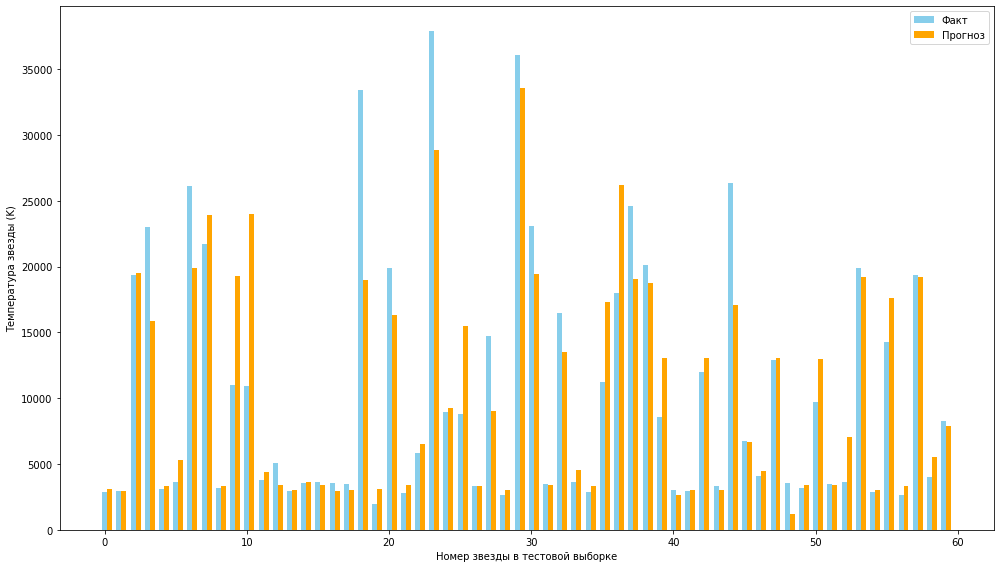

In [ ]:
visual.plot_temp_bar(y_test, baseline_test_preds)


Судя по графику большая часть прогнозов близка к факту. Для многих звезд фактическое и прогнозное значение почти одинаковы — модель в целом обучилась и предсказывает адекватно. Модель сильнее всего ошибается при высоких температурах. У большинства таких объектов предсказанное значение ниже фактического, т.е. **модель склонна недооценивать экстремально высокие значения**. 

<b>Вывод по разделу "Построение базовой нейронной сети"</b>

В рамках построения базовой модели было сделано следующее:
1. Для сглаживания неоднородности данных были добавлены логарифм и квадрат от светимости. Данные разделены по star_type с разбиением каждой группы на обучающую и тестовую выборки (75%/25%). 

2. Для предобработки признаков был собран пайплайн: категориальные переменные кодировались через OneHotEncoder, количественные — стандартизировались через StandardScaler.

3. В рамках PyTorch была реализована модель BaselineNet как класс nn.Module с тремя полносвязными слоями, ReLU-активацией (и ее вариациями) и Dropout для борьбы с переобучением. Архитектура выбрана с убывающим количеством нейронов от входного слоя (равного числу признаков) до одного выходного нейрона. Наибольший Dropout задан для первого скрытого слоя. Обучение велось с использованием оптимизатора Adam и L2-регуляризации (weight_decay). Функция потерь — MSELoss, метрика качества — RMSE, вычисляемая каждые 100 эпох.

**Результат:** на 1000 эпохах модель достигла RMSE = 4164, что лучше целевого значения (≤ 4500). Построенный график «Факт — Прогноз» показал, что модель хорошо воспроизводит температурные значения для большинства объектов, но недооценивает экстремально высокие температуры.

## Улучшение нейронной сети

Попробуем улучшить метрику с помощью подбора значения для dropout и размера батча с использованием библиотеки optuna. Архитектуру нейронной сети оставим без изменений. 

In [ ]:
def objective(trial: optuna.Trial):
    dropout_rate_1 = trial.suggest_float("dropout_1", 0.0, 0.5, step=0.05)
    dropout_rate_2 = trial.suggest_float("dropout_2", 0.0, 0.1, step=0.05)
    dropout_rate_3 = trial.suggest_float("dropout_3", 0.0, 0.1, step=0.05)
    batch_size = trial.suggest_int("batch_size", 4, 30, step=2)

    net = BaselineNet(n_in_neurons, n_hidden_neurons_1, n_hidden_neurons_2, n_hidden_neurons_3,
                      n_out_neurons, dropout_rate_1, dropout_rate_2, dropout_rate_3)

    test_preds, trained_net = train_model(net, X_train, y_train, X_test, y_test, batch_size, num_epochs)
    
    rmse_opt = mean_squared_error(y_test.numpy(), test_preds.detach().numpy(), squared=False)
            
    return rmse_opt


In [ ]:
study = optuna.create_study(direction="minimize",
                            sampler=TPESampler(seed=RANDOM_STATE),
                            pruner=optuna.pruners.HyperbandPruner())
study.optimize(objective, n_trials=100)


[I 2025-08-12 17:28:35,304] A new study created in memory with name: no-name-53742d33-d2cb-4e76-98ef-ea20c9b389d1


На эпохе 0 RMSE = 14039.853515625
На эпохе 100 RMSE = 14035.4423828125
На эпохе 200 RMSE = 14032.0830078125
На эпохе 300 RMSE = 14028.7685546875
На эпохе 400 RMSE = 14025.46875
На эпохе 500 RMSE = 14022.1728515625
На эпохе 600 RMSE = 14018.880859375
На эпохе 700 RMSE = 14015.5888671875
На эпохе 800 RMSE = 14012.298828125
На эпохе 900 RMSE = 14009.01171875


[I 2025-08-12 17:28:44,796] Trial 0 finished with value: 14005.7568359375 and parameters: {'dropout_1': 0.2, 'dropout_2': 0.1, 'dropout_3': 0.1, 'batch_size': 20}. Best is trial 0 with value: 14005.7568359375.


На эпохе 999 RMSE = 14005.7568359375
На эпохе 0 RMSE = 14040.1689453125
На эпохе 100 RMSE = 12272.1162109375
На эпохе 200 RMSE = 7760.31640625
На эпохе 300 RMSE = 6557.78076171875
На эпохе 400 RMSE = 5803.76171875
На эпохе 500 RMSE = 5395.171875
На эпохе 600 RMSE = 5140.50830078125
На эпохе 700 RMSE = 4937.03466796875
На эпохе 800 RMSE = 4796.3671875
На эпохе 900 RMSE = 4668.60791015625


[I 2025-08-12 17:28:52,325] Trial 1 finished with value: 4555.37548828125 and parameters: {'dropout_1': 0.05, 'dropout_2': 0.0, 'dropout_3': 0.0, 'batch_size': 28}. Best is trial 1 with value: 4555.37548828125.


...

На эпохе 999 RMSE = 4090.22705078125
На эпохе 0 RMSE = 14039.921875
На эпохе 100 RMSE = 6657.08837890625
На эпохе 200 RMSE = 5515.03271484375
На эпохе 300 RMSE = 4982.896484375
На эпохе 400 RMSE = 4698.5439453125
На эпохе 500 RMSE = 4522.39501953125
На эпохе 600 RMSE = 4390.35693359375
На эпохе 700 RMSE = 4302.9404296875
На эпохе 800 RMSE = 4243.59423828125
На эпохе 900 RMSE = 4223.94775390625


[I 2025-08-12 18:18:13,083] Trial 98 finished with value: 4201.40087890625 and parameters: {'dropout_1': 0.45, 'dropout_2': 0.1, 'dropout_3': 0.05, 'batch_size': 8}. Best is trial 53 with value: 3998.318115234375.


На эпохе 999 RMSE = 4201.40087890625
На эпохе 0 RMSE = 14039.7568359375
На эпохе 100 RMSE = 5542.19140625
На эпохе 200 RMSE = 4718.14599609375
На эпохе 300 RMSE = 4403.16650390625
На эпохе 400 RMSE = 4224.73193359375
На эпохе 500 RMSE = 4150.11962890625
На эпохе 600 RMSE = 4125.02783203125
На эпохе 700 RMSE = 4091.507080078125
На эпохе 800 RMSE = 4071.54638671875
На эпохе 900 RMSE = 4058.9228515625


[I 2025-08-12 18:18:56,708] Trial 99 finished with value: 4044.0771484375 and parameters: {'dropout_1': 0.5, 'dropout_2': 0.0, 'dropout_3': 0.05, 'batch_size': 4}. Best is trial 53 with value: 3998.318115234375.


На эпохе 999 RMSE = 4044.0771484375


In [ ]:
study.best_params


{'dropout_1': 0.4, 'dropout_2': 0.0, 'dropout_3': 0.05, 'batch_size': 4}

In [ ]:
dropout_rate_1 = 0.4
dropout_rate_2 = 0.00
dropout_rate_3 = 0.05

net_opt = BaselineNet(n_in_neurons, n_hidden_neurons_1, n_hidden_neurons_2, n_hidden_neurons_3,
                  n_out_neurons, dropout_rate_1, dropout_rate_2, dropout_rate_3)

batch_size = 4


In [ ]:
final_test_preds, final_model = train_model(net_opt, X_train, y_train, X_test, y_test, batch_size, num_epochs)


На эпохе 0 RMSE = 14039.970703125
На эпохе 100 RMSE = 5551.80419921875
На эпохе 200 RMSE = 4687.96484375
На эпохе 300 RMSE = 4363.8671875
На эпохе 400 RMSE = 4196.84619140625
На эпохе 500 RMSE = 4141.6083984375
На эпохе 600 RMSE = 4116.85595703125
На эпохе 700 RMSE = 4093.737548828125
На эпохе 800 RMSE = 4074.54443359375
На эпохе 900 RMSE = 4056.365478515625
На эпохе 999 RMSE = 4044.754150390625


В результате подбора гиперпараметров нейросети с использованием перебора по dropout и batch_size удалось улучшить качество модели. Базовая модель (без подбора) показала RMSE = 4164.

При использовании оптимальных параметров (dropout_1 = 0.4, dropout_2 = 0.00, dropout_3 = 0.05, batch_size = 4) RMSE снизился до 4044, что соответствует **улучшению на ~3% относительно базового варианта.**

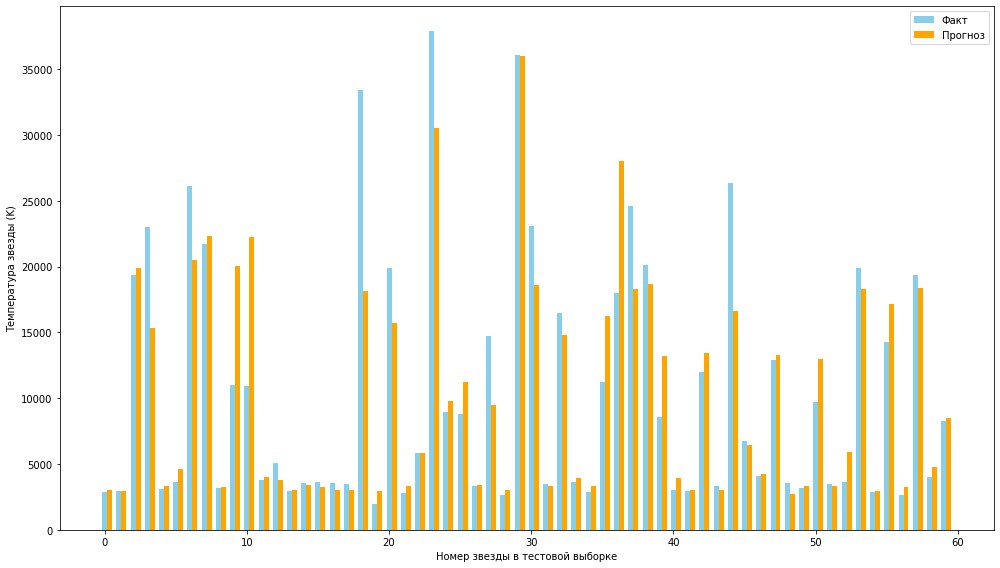

In [ ]:
visual.plot_temp_bar(y_test, final_test_preds)


На графике видно, что предсказания при экстремальных температурах стали ближе к фактическому значению. Это ярко выраженно, например, на звезде №29. Для наглядности построим сравнительный график предсказаний на базовой и улучшенной модели. 

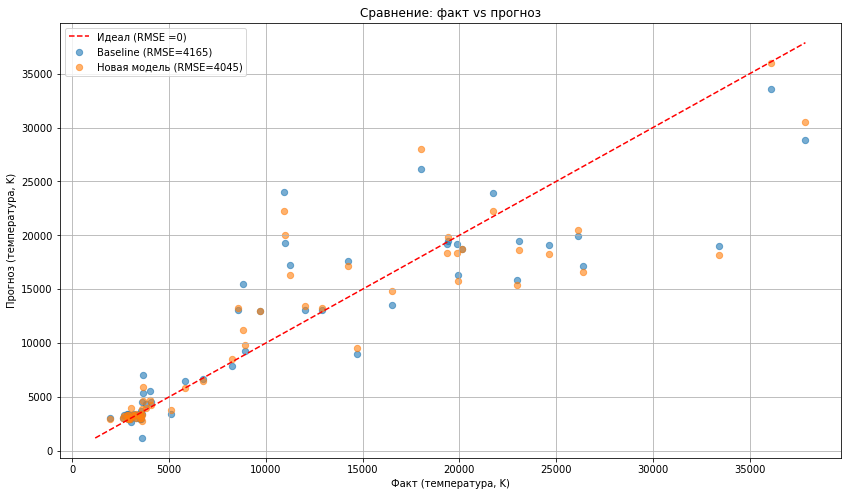

In [ ]:
y_test_np = y_test.detach().numpy().flatten()
baseline_test_preds_np = baseline_test_preds.detach().numpy().flatten()
final_test_preds_np = final_test_preds.detach().numpy().flatten()

rmse_baseline = mean_squared_error(y_test_np, baseline_test_preds_np, squared=False)
rmse_new = mean_squared_error(y_test_np, final_test_preds_np, squared=False)

min_val = float(np.min([y_test_np.min(), baseline_test_preds_np.min(), final_test_preds_np.min()]))
max_val = float(np.max([y_test_np.max(), baseline_test_preds_np.max(), final_test_preds_np.max()]))

plt.figure(figsize=(14, 8))
plt.scatter(y_test_np, baseline_test_preds_np, alpha=0.6, label=f'Baseline (RMSE={rmse_baseline:.0f})', s=40)
plt.scatter(y_test_np, final_test_preds_np, alpha=0.6, label=f'Новая модель (RMSE={rmse_new:.0f})', s=40)
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Идеал (RMSE =0)')

plt.xlabel("Факт (температура, K)")
plt.ylabel("Прогноз (температура, K)")
plt.title("Сравнение: факт vs прогноз")
plt.legend(loc='best')
plt.grid(True)
plt.xlim(min_val - 0.05*(max_val-min_val), max_val + 0.05*(max_val-min_val))
plt.ylim(min_val - 0.05*(max_val-min_val), max_val + 0.05*(max_val-min_val))
plt.show()


Линия "Идеал" на графике отражает ситуацию когда предсказание модели в точности совпадает с фактичсеским значением. Чем ближе на графике точка конкретного предсказания к этой линии, тем точнее модель предсказала температуру звезды. 

Из графика видно, что у обеих моделей предсказания предсказания в целом коррелируют с фактическими значениями — облако точек вытянуто вдоль линии идеала.  Однако, есть заметные отклонения при высоких значениях фактической температуры — в области выше 10 000 градусов модели теряют точность, и разброс увеличивается.

У улучшеной модели значение RMSE 4044, у базовой - 4164 (~ 3% улучшения). Улучшение небольшое, но судя по графику оно устойчиво по всему диапазону значений. У новой модели часть точек ближе к линии "идеала" в зоне от 10 000 до 25 000 градусов. При высоких значениях (выше 25 000 градусов) обе модели ошибаются сильнее и разброс тут уже выше.

<b>Вывод по разделу "Улучшение нейронной сети"</b>

В результате подбора гиперпараметров нейросети с использованием перебора по dropout и batch_size удалось улучшить качество модели.

| Параметр	| Baseline модель |	Улучшенная модель |
| --------- | --------------- | ----------------- |
| Dropout 1	|       0.3       |	       0.4        |
| Dropout 2 |	    0.1	      |       0.00        |
| Dropout 3	|       0.1	      |       0.05        |
| Batch size|	     10       |        4          |
|   RMSE	|       4164      |      4044         |

При сравнительном анализе улучшение результатов дало:
- увеличение параметра dropout на первом слое позволило "обнулять" нейроны на ранеей стадии обучения и снизить переобучение на первом слое.
- снижение параметра dropout на последующих слоях позволило лучше сохранить данные и повысить стабильность финальных прогнозов, за счет меньшей потери данных на финальном этапе обучения.
- уменьшение размера батча позволило делать более частые обновления весов, что, вероятно, привело к повышению способности к обобщению.

**Результат:** Комбинация более сильной регуляризации (dropout) на первом слое и мягкой на последних, более частые обновления весов улучшили баланс между пере- и недообучением и привели к повышению метрики RMSE на 3%. 

## Выводы

В ходе работы над проектом по предсказанию температуры звезд по заказу обсерватории "Недо на ладони" были разработаны и протестированы две модификации нейронной сети на архитектуре BaselineNet с фиксированным числом слоёв и нейронов:

| Слой               | Кол-во нейронов | Функция активации | Dropout    |
| -------------------| --------------- | ----------------- | ---------- |
| n_in_neurons       | 21              | -                 | -          |
| n_hidden_neurons_1 | 12              | ReLU              | 0.3 / 0.4  |
| n_hidden_neurons_2 | 8               | LeakyReLU(0.1)    | 0.1 / 0.00 |
| n_hidden_neurons_3 | 4               | ELU               | 0.1 / 0.05 |
| n_out_neurons      | 1               | —                 | —          |

Сравнительные параметры моделей:

| Параметр	| Baseline модель |	Улучшенная модель |
| --------- | --------------- | ----------------- |
| Dropout 1	|       0.3       |	       0.4        |
| Dropout 2 |	    0.1	      |       0.00        |
| Dropout 3	|       0.1	      |       0.05        |
| Batch size|	     10       |        4          |
|   RMSE	|       4164      |      4044         |


Результаты:
1. **Baseline модель** показала RMSE = 4164. Модель продемонстрировала удовлетворительное качество, но имела тенденцию к недообучению на сложных случаях, что выражалось в большем разбросе предсказаний.
2. **Улучшенная модель**, полученная в результате подбора гиперпараметров с использованием Optuna, обеспечила RMSE = 4044. Изменения гиперпараметров (увеличение dropout на первом слое, уменьшение dropout на последующих слоях, уменьшение размера мини-батча) позволили улучшить баланс между регуляризацией и сохранением информативных признаков, а также обеспечить более частое обновление весов.

Сравнение моделей:
* Улучшенная модель показала снижение RMSE на ~3% по сравнению с исходной.
* Графический анализ «факт — прогноз» показал, что новая модель ближе к фактическим значениям на большей части диапазона значений.
* На высоких значениях целевой переменной обе модели имеют схожие колебания, однако улучшенная модель реже даёт значительные отклонения.

Применение подбора гиперпараметров позволило повысить точность прогнозирования и добиться целевого значения метрики RMSE < 4500. Улучшения достигнуты без изменения архитектуры слоёв и функций активации, что подчёркивает значимость оптимизации параметров обучения при фиксированной архитектуре.